In [1]:
import torch
from sentence_transformers import models, SentenceTransformer
import os
from sentence_transformers.evaluation import InformationRetrievalEvaluator, SequentialEvaluator
from datasets import Dataset
import json
import numpy as np
from collections import defaultdict
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

/u/modelfactory/.conda/envs/lab/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class ScoreAggregator:
    def __init__(self, datasets):
        lengths = [len(dataset) for dataset in datasets]
        total_size = sum(lengths)
        self.proportions = [length / total_size for length in lengths]
    def __call__(self, scores):
        # weighted average
        return sum([score * proportion for score, proportion in zip(scores, self.proportions)])

In [20]:
short_names_tasks = {
    'asset_to_related_sensors': 'A2S',
    'asset_fault_to_sensor': 'FM2S',
    'asset_sensor_to_fault': 'S2FM',
    'asset_fm_to_components': 'FM2CMP',
    'component_to_failure_mode': 'C2FM',
    'eq_subunit_to_unit': 'EU2SU',
    'eq_to_class_type': 'E2CLT',
    'eq_to_category': 'E2CAT',
    'failure_desc_to_class': 'FM2CLS'
}
reversed_dict = dict(zip(short_names_tasks.values(), short_names_tasks.keys()))

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [5]:
model_path = 'google-bert_bert-base-uncased_fmsr_ft_bs32_poolmean_pdesc0.0_positiveratio_<p_positive>seed_<seed>'

In [11]:
ft_path

'google-bert_bert-base-uncased_fmsr_ft_bs32_poolmean_pdesc0.0_positiveratio_1.0seed_46'

## Ablation varying pdesc for multiple seeds and different in batch positive ratio

In [53]:
all_scores = defaultdict(list)
# inbatch_neg = True
p_desc = 0.0
for seed in range(42, 47):
    for p_positive in np.arange(0, 1.125, 0.125):
        p_positive = str(p_positive)
        ft_path = f'../models/google-bert_bert-base-uncased_fmsr_ft_bs32_poolmean_pdesc{p_desc}_positiveratio_{p_positive}seed_{seed}'
        try:
            oldest_ckpt = min([int(path.split('-')[-1]) for path in os.listdir(ft_path) if 'checkpoint' in path])
        except:
            print(f'failed to find ckpt for {oldest_ckpt}')
            continue
        ckpt_path = f'../{ft_path}/checkpoint-{oldest_ckpt}'
        base_data_path = f'../data/industrial/processed/ablation/p_desc_{p_desc}_seed_{seed}'
        test_dataset = Dataset.from_json(f'../{base_data_path}/test.json')
        agg = ScoreAggregator(test_dataset)
        with open(f'{base_data_path}/all_tasks_dataset.json', 'r') as f:
            data = json.load(f)
        id_to_corpus = {val: key for key, val in data['corpus_to_id'].items()}
        id_to_query = {val: key for key, val in data['query_to_id'].items()}
        query_to_doc = {int(key): val for key, val in data['query_to_doc'].items()}
        unique_tasks = list(data['dataset_to_queries'].keys())
        task_dataset = {'test': {}}
        for task in unique_tasks:
            task_dataset['test'][task] = test_dataset.filter(lambda x: x['task'] == task)
            evaluators = {'test': []}
        for split in ['test']:
            for task in task_dataset[split]:     
                task_queries = {data['query_to_id'][item['sentence1']]: item['sentence1'] for item in task_dataset[split][task]}
                evaluator = InformationRetrievalEvaluator(
                    queries=task_queries,
                    corpus=id_to_corpus,
                    relevant_docs=query_to_doc,
                    name=f"{task}_{split}"
                )
                evaluators[split].append(evaluator)
        evaluator = InformationRetrievalEvaluator(
            queries=task_queries,
            corpus=id_to_corpus,
            relevant_docs=query_to_doc,
            name=f"{task}_{split}"
        )
        evaluators[split] = SequentialEvaluator(evaluators[split], main_score_function=agg)
        kwargs = {}
        if 'Alibaba' in ft_path or 'mistral' in ft_path or 'granite' in ft_path:
            kwargs = {'torch_dtype': torch.bfloat16}
        kwargs = {'torch_dtype': torch.bfloat16}
        kwargs['trust_remote_code'] = True
        
        
        # model = SentenceTransformer(model_id_after, device=device, trust_remote_code=True, model_kwargs=kwargs)
        print(f'loading model {ckpt_path}')
        transformer = models.Transformer(ckpt_path, model_args=kwargs)
        pooling = models.Pooling(transformer.get_word_embedding_dimension(), pooling_mode="lasttoken")
        normalize = models.Normalize()
        model = SentenceTransformer(modules=[transformer, pooling, normalize], device=device, trust_remote_code=True, model_kwargs=kwargs)
        print(f'evaluating model {ckpt_path}')
        scores = evaluators['test'](model)
        print('evaluation model after')
        all_scores[p_positive].append(scores)

loading model models/google-bert_bert-base-uncased_fmsr_ft_bs32_poolmean_pdesc0.0_positiveratio_0.0seed_42/checkpoint-2800
evaluating model models/google-bert_bert-base-uncased_fmsr_ft_bs32_poolmean_pdesc0.0_positiveratio_0.0seed_42/checkpoint-2800
evaluation model after
loading model models/google-bert_bert-base-uncased_fmsr_ft_bs32_poolmean_pdesc0.0_positiveratio_0.125seed_42/checkpoint-2700
evaluating model models/google-bert_bert-base-uncased_fmsr_ft_bs32_poolmean_pdesc0.0_positiveratio_0.125seed_42/checkpoint-2700
evaluation model after
loading model models/google-bert_bert-base-uncased_fmsr_ft_bs32_poolmean_pdesc0.0_positiveratio_0.25seed_42/checkpoint-2500
evaluating model models/google-bert_bert-base-uncased_fmsr_ft_bs32_poolmean_pdesc0.0_positiveratio_0.25seed_42/checkpoint-2500
evaluation model after
loading model models/google-bert_bert-base-uncased_fmsr_ft_bs32_poolmean_pdesc0.0_positiveratio_0.375seed_42/checkpoint-2400
evaluating model models/google-bert_bert-base-uncased

In [21]:
with open('results/ablation/varying_p_positive_ablation.json', 'r') as f:
    all_scores = json.load(f)

In [22]:
all_tasks = np.unique([metric.split('_test')[0] for metric in all_scores[str(0.0)][0].keys()])

In [23]:
performance_per_task = []
dfs = []
for task in all_tasks:
    if task == 'sequential_score':
        continue
    for p_positive in np.arange(0, 1.125, 0.125):
        p_positive = str(p_positive)
        # curr_model = new_key.replace('pdesc1.0', 'pdesc'+str(p_desc))
        # scores = [item[task+'_test_cosine_'+'map@100'] for item in all_scores[p_desc]]
        for item in all_scores[p_positive]:
            performance_per_task.append([task, p_positive, item[task+'_test_cosine_'+'map@100']])
df = pd.DataFrame(performance_per_task, columns=['task', 'p_positive', 'score'])

In [24]:
df.p_positive = df.p_positive.astype(float)

In [25]:
df['positive ratio'] = df.pop('p_positive')

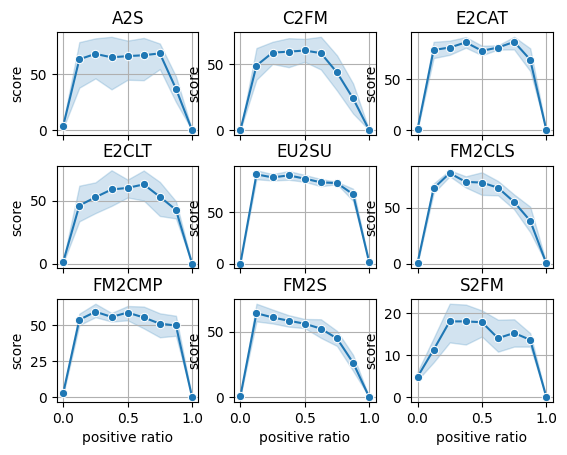

In [26]:
nrows = 3
ncols = 3
fig, ax = plt.subplots(nrows=nrows, sharex=True, ncols=ncols)
# fig.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.25)
for i, abbrv_task in enumerate(sorted(reversed_dict.keys())):
    task = reversed_dict[abbrv_task]
    if task == 'sequential_score':
        continue
    # if abbrv_task == 'FM2CLS':
    #     ax[i//nrows][i%ncols].set_yticks([87, 90, 93])
    ax[i//nrows][i%ncols].set_title(abbrv_task)   
    sel_df = df[df.task==task].copy()  
    rounded_scores = [round((x * 100), 0) for x in sel_df.score.tolist()]
    sel_df.score = rounded_scores
    # ax[i//nrows][i%ncols].plot([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], rounded_scores)
    marker = 'o'
    if i//nrows == nrows - 1 and i%ncols == ncols - 1:
        sns.lineplot(sel_df, x='positive ratio', y='score', ax=ax[i//nrows][i%ncols], marker=marker)
        # sns.move_legend(ax[i//nrows][i%ncols], 'lower right', bbox_to_anchor=(1, -1))
    else:
        sns.lineplot(sel_df, x='positive ratio', y='score', ax=ax[i//nrows][i%ncols], marker=marker)
    ax[i//nrows][i%ncols].grid(True)
    # if i//nrows == nrows - 1:
    #     ax[i//nrows][i%ncols].set_xticks(np.arange(0, 1.125, 0.25))

In [64]:
with open('results/ablation/varying_p_positive_ablation.json', 'w') as f:
    f.write(json.dumps(all_scores))

## Ablation varying pdesc for multiple seeds and different losses

In [12]:
all_scores = {'inbatch': defaultdict(list), 'no_inbatch': defaultdict(list)}
# inbatch_neg = True
for inbatch_neg in [False, True]:
    for seed in range(42, 47):
        for p_desc in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
            inbatch_neg_str = 'inbatchnegs_' if inbatch_neg else ''
            ft_path = f'models/google-bert_bert-base-uncased_fmsr_ft_bs32_poolmean_{inbatch_neg_str}pdesc{p_desc}_positiveratio_0.5seed_{seed}'
            try:
                oldest_ckpt = min([int(path.split('-')[-1]) for path in os.listdir(ft_path) if 'checkpoint' in path])
            except:
                print(f'failed to find ckpt for {oldest_ckpt}')
                continue
            ckpt_path = f'{ft_path}/checkpoint-{oldest_ckpt}'
            base_data_path = f'data/industrial/processed/ablation/p_desc_{p_desc}_seed_{seed}'
            test_dataset = Dataset.from_json(f'{base_data_path}/test.json')
            agg = ScoreAggregator(test_dataset)
            with open(f'{base_data_path}/all_tasks_dataset.json', 'r') as f:
                data = json.load(f)
            id_to_corpus = {val: key for key, val in data['corpus_to_id'].items()}
            id_to_query = {val: key for key, val in data['query_to_id'].items()}
            query_to_doc = {int(key): val for key, val in data['query_to_doc'].items()}
            unique_tasks = list(data['dataset_to_queries'].keys())
            task_dataset = {'test': {}}
            for task in unique_tasks:
                task_dataset['test'][task] = test_dataset.filter(lambda x: x['task'] == task)
                evaluators = {'test': []}
            for split in ['test']:
                for task in task_dataset[split]:     
                    task_queries = {data['query_to_id'][item['sentence1']]: item['sentence1'] for item in task_dataset[split][task]}
                    evaluator = InformationRetrievalEvaluator(
                        queries=task_queries,
                        corpus=id_to_corpus,
                        relevant_docs=query_to_doc,
                        name=f"{task}_{split}"
                    )
                    evaluators[split].append(evaluator)
            evaluator = InformationRetrievalEvaluator(
                queries=task_queries,
                corpus=id_to_corpus,
                relevant_docs=query_to_doc,
                name=f"{task}_{split}"
            )
            evaluators[split] = SequentialEvaluator(evaluators[split], main_score_function=agg)
            kwargs = {}
            if 'Alibaba' in ft_path or 'mistral' in ft_path or 'granite' in ft_path:
                kwargs = {'torch_dtype': torch.bfloat16}
            kwargs = {'torch_dtype': torch.bfloat16}
            kwargs['trust_remote_code'] = True
            
            
            # model = SentenceTransformer(model_id_after, device=device, trust_remote_code=True, model_kwargs=kwargs)
            print(f'loading model {ckpt_path}')
            transformer = models.Transformer(ckpt_path, model_args=kwargs)
            pooling = models.Pooling(transformer.get_word_embedding_dimension(), pooling_mode="lasttoken")
            normalize = models.Normalize()
            model = SentenceTransformer(modules=[transformer, pooling, normalize], device=device, trust_remote_code=True, model_kwargs=kwargs)
            print(f'evaluating model {ckpt_path}')
            scores = evaluators['test'](model)
            print('evaluation model after')
            inbatch_dict_str = 'inbatch' if inbatch_neg else 'no_inbatch'
            all_scores[inbatch_dict_str][p_desc].append(scores)

loading model models/google-bert_bert-base-uncased_fmsr_ft_bs32_poolmean_pdesc0.0_positiveratio_0.5seed_42/checkpoint-2100
evaluating model models/google-bert_bert-base-uncased_fmsr_ft_bs32_poolmean_pdesc0.0_positiveratio_0.5seed_42/checkpoint-2100
evaluation model after
loading model models/google-bert_bert-base-uncased_fmsr_ft_bs32_poolmean_pdesc0.2_positiveratio_0.5seed_42/checkpoint-2300
evaluating model models/google-bert_bert-base-uncased_fmsr_ft_bs32_poolmean_pdesc0.2_positiveratio_0.5seed_42/checkpoint-2300
evaluation model after
loading model models/google-bert_bert-base-uncased_fmsr_ft_bs32_poolmean_pdesc0.4_positiveratio_0.5seed_42/checkpoint-2900
evaluating model models/google-bert_bert-base-uncased_fmsr_ft_bs32_poolmean_pdesc0.4_positiveratio_0.5seed_42/checkpoint-2900
evaluation model after
loading model models/google-bert_bert-base-uncased_fmsr_ft_bs32_poolmean_pdesc0.6_positiveratio_0.5seed_42/checkpoint-2500
evaluating model models/google-bert_bert-base-uncased_fmsr_ft

In [24]:
# all_keys = list(all_scores.keys())
# for key in all_keys:
#     new_key = '/'.join(key.split('/')[:-1])
#     all_scores[new_key] = all_scores.pop(key)

In [27]:
with open('results/ablation/varying_pdesc_ablation.json', 'r') as f:
    all_scores = json.load(f)

In [28]:
all_tasks = np.unique([metric.split('_test')[0] for metric in all_scores['inbatch']['0.0'][0].keys()])

In [29]:
performance_per_task = {'inbatch':[], 'no_inbatch':[]}
dfs = []
for inbatch in [False, True]:
    for task in all_tasks:
        if task == 'sequential_score':
            continue
        for p_desc in [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]:
            # curr_model = new_key.replace('pdesc1.0', 'pdesc'+str(p_desc))
            # scores = [item[task+'_test_cosine_'+'map@100'] for item in all_scores[p_desc]]
            inbatch_str = 'inbatch' if inbatch else 'no_inbatch'
            for item in all_scores[inbatch_str][str(p_desc)]:
                performance_per_task[inbatch_str].append([task, p_desc, item[task+'_test_cosine_'+'map@100']])
    df = pd.DataFrame(performance_per_task[inbatch_str], columns=['task', 'p_desc', 'score'])
    dfs.append(df)

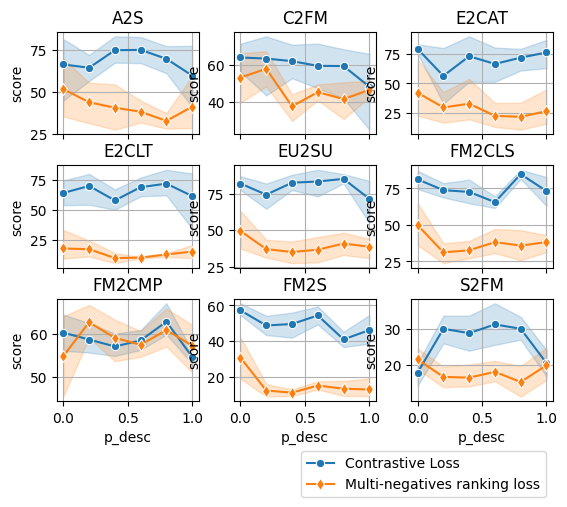

In [30]:
nrows = 3
ncols = 3
fig, ax = plt.subplots(nrows=nrows, sharex=True, ncols=ncols)
# fig.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.25)
for i, abbrv_task in enumerate(sorted(reversed_dict.keys())):
    task = reversed_dict[abbrv_task]
    if task == 'sequential_score':
        continue
    # if abbrv_task == 'FM2CLS':
    #     ax[i//nrows][i%ncols].set_yticks([87, 90, 93])
    ax[i//nrows][i%ncols].set_title(abbrv_task)
    for df, loss_method in zip(dfs, ['Contrastive Loss', 'Multi-negatives ranking loss']):
        sel_df = df[df.task==task].copy()  
        rounded_scores = [round((x * 100), 0) for x in sel_df.score.tolist()]
        sel_df.score = rounded_scores
        # ax[i//nrows][i%ncols].plot([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], rounded_scores)
        marker = 'o' if loss_method == 'Contrastive Loss' else 'd'
        if i//nrows == nrows - 1 and i%ncols == ncols - 1:
            label = loss_method
            sns.lineplot(sel_df, x='p_desc', y='score', ax=ax[i//nrows][i%ncols], label=loss_method, marker=marker)
            sns.move_legend(ax[i//nrows][i%ncols], 'lower right', bbox_to_anchor=(1, -1))
        else:
            sns.lineplot(sel_df, x='p_desc', y='score', ax=ax[i//nrows][i%ncols], marker=marker)
        ax[i//nrows][i%ncols].grid(True)

In [32]:
with open('results/ablation/ablation.json', 'w') as f:
    f.write(json.dumps(all_scores))

## Ablation comparison between multinegativebatchloss and contrastive loss

In [20]:
model_ids = [
    'google-bert_bert-base-uncased', 'BAAI_bge-large-en-v1.5', 'sentence-transformers_all-mpnet-base-v2',
    'intfloat_e5-mistral-7b-instruct', 'Alibaba-NLP_gte-qwen2-7B-instruct'
]

In [21]:
p_desc = 0.0
seed = 42
path = f'models/<model_id>_fmsr_ft_bs32_poolmean_inbatchnegs_pdesc{p_desc}_positiveratio_0.5seed_{seed}'
base_data_path = f'data/industrial/processed/ablation/p_desc_{p_desc}_seed_{seed}'
all_scores_diff_loss = defaultdict(list)
for model_id in model_ids:
    for multistage in [False, True]:
        ckpt_path = path.replace('<model_id>', model_id)
        if multistage:
            ckpt_path += '_multistage'
        try:
            oldest_ckpt = min([int(path.split('-')[-1]) for path in os.listdir(ckpt_path) if 'checkpoint' in path])
        except:
            print(f'failed to find ckpt for {oldest_ckpt}')
            continue
        ckpt_path = f'{ckpt_path}/checkpoint-{oldest_ckpt}'
        test_dataset = Dataset.from_json(f'{base_data_path}/test.json')
        agg = ScoreAggregator(test_dataset)
        with open(f'{base_data_path}/all_tasks_dataset.json', 'r') as f:
            data = json.load(f)
        id_to_corpus = {val: key for key, val in data['corpus_to_id'].items()}
        id_to_query = {val: key for key, val in data['query_to_id'].items()}
        query_to_doc = {int(key): val for key, val in data['query_to_doc'].items()}
        unique_tasks = list(data['dataset_to_queries'].keys())
        task_dataset = {'test': {}}
        for task in unique_tasks:
            task_dataset['test'][task] = test_dataset.filter(lambda x: x['task'] == task)
            evaluators = {'test': []}
        for split in ['test']:
            for task in task_dataset[split]:     
                task_queries = {data['query_to_id'][item['sentence1']]: item['sentence1'] for item in task_dataset[split][task]}
                evaluator = InformationRetrievalEvaluator(
                    queries=task_queries,
                    corpus=id_to_corpus,
                    relevant_docs=query_to_doc,
                    name=f"{task}_{split}"
                )
                evaluators[split].append(evaluator)
        evaluator = InformationRetrievalEvaluator(
            queries=task_queries,
            corpus=id_to_corpus,
            relevant_docs=query_to_doc,
            name=f"{task}_{split}"
        )
        evaluators[split] = SequentialEvaluator(evaluators[split], main_score_function=agg)
        kwargs = {}
        if 'Alibaba' in ckpt_path or 'mistral' in ckpt_path or 'granite' in ckpt_path:
            kwargs = {'torch_dtype': torch.bfloat16}
        kwargs = {'torch_dtype': torch.bfloat16}
        kwargs['trust_remote_code'] = True
        
        
        # model = SentenceTransformer(model_id_after, device=device, trust_remote_code=True, model_kwargs=kwargs)
        print(f'loading model {ckpt_path}')
        transformer = models.Transformer(ckpt_path, model_args=kwargs)
        pooling = models.Pooling(transformer.get_word_embedding_dimension(), pooling_mode="lasttoken")
        normalize = models.Normalize()
        model = SentenceTransformer(modules=[transformer, pooling, normalize], device=device, trust_remote_code=True, model_kwargs=kwargs)
        # print(f'evaluating model {ckpt_path}')
        scores = evaluators['test'](model)
        all_scores_diff_loss[model_id].append(scores)

loading model models/google-bert_bert-base-uncased_fmsr_ft_bs32_poolmean_inbatchnegs_pdesc0.0_positiveratio_0.5seed_42/checkpoint-1500
loading model models/google-bert_bert-base-uncased_fmsr_ft_bs32_poolmean_inbatchnegs_pdesc0.0_positiveratio_0.5seed_42_multistage/checkpoint-900
loading model models/BAAI_bge-large-en-v1.5_fmsr_ft_bs32_poolmean_inbatchnegs_pdesc0.0_positiveratio_0.5seed_42/checkpoint-200
loading model models/BAAI_bge-large-en-v1.5_fmsr_ft_bs32_poolmean_inbatchnegs_pdesc0.0_positiveratio_0.5seed_42_multistage/checkpoint-800
loading model models/sentence-transformers_all-mpnet-base-v2_fmsr_ft_bs32_poolmean_inbatchnegs_pdesc0.0_positiveratio_0.5seed_42/checkpoint-300
loading model models/sentence-transformers_all-mpnet-base-v2_fmsr_ft_bs32_poolmean_inbatchnegs_pdesc0.0_positiveratio_0.5seed_42_multistage/checkpoint-600
loading model models/intfloat_e5-mistral-7b-instruct_fmsr_ft_bs32_poolmean_inbatchnegs_pdesc0.0_positiveratio_0.5seed_42/checkpoint-300


Loading checkpoint shards: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:34<00:00, 17.12s/it]


loading model models/intfloat_e5-mistral-7b-instruct_fmsr_ft_bs32_poolmean_inbatchnegs_pdesc0.0_positiveratio_0.5seed_42_multistage/checkpoint-900


Loading checkpoint shards: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:02<00:00,  1.35s/it]


failed to find ckpt for 900
failed to find ckpt for 900


In [22]:
short_names_tasks = {
    'asset_to_related_sensors': 'A2S',
    'asset_fault_to_sensor': 'FM2S',
    'asset_sensor_to_fault': 'S2FM',
    'asset_fm_to_components': 'FM2CMP',
    'component_to_failure_mode': 'C2FM',
    'eq_subunit_to_unit': 'ES2U',
    'eq_to_class_type': 'E2CLT',
    'eq_to_category': 'EQ2CAT',
    'failure_desc_to_class': 'FM2CLS'
}
reversed_dict = dict(zip(short_names_tasks.values(), short_names_tasks.keys()))

In [25]:
scores_df = []
for model_id in model_ids:
    print("*"*90)
    for i, abbrv_task in enumerate(sorted(reversed_dict.keys())):
        task = reversed_dict[abbrv_task]
        if len(all_scores_diff_loss[model_id]) == 0:
            print(f'empty scores for {model_id}, skipping')
            continue
        score_before = all_scores_diff_loss[model_id][0][task+'_test_cosine_'+'map@100']
        score_after = all_scores_diff_loss[model_id][1][task+'_test_cosine_'+'map@100']
        print(f'model: {model_id}, task: {task} before: {score_before}, after: {score_after}')
        scores_df.append([model_id, abbrv_task, score_before, score_after])
scores_df = pd.DataFrame(scores_df, columns=['model_id', 'task', 'score_contrastive', 'score_inbatch_neg'])

******************************************************************************************
model: google-bert_bert-base-uncased, task: asset_to_related_sensors before: 0.346413325544928, after: 0.292373769757482
model: google-bert_bert-base-uncased, task: component_to_failure_mode before: 0.76168430335097, after: 0.7754629629629629
model: google-bert_bert-base-uncased, task: eq_to_class_type before: 0.4520578321313778, after: 0.6039234181426082
model: google-bert_bert-base-uncased, task: eq_to_category before: 0.9358678709383422, after: 0.9522205811234702
model: google-bert_bert-base-uncased, task: eq_subunit_to_unit before: 0.7252798537331165, after: 0.7548993996130876
model: google-bert_bert-base-uncased, task: failure_desc_to_class before: 0.7847503403805461, after: 0.7784804860468414
model: google-bert_bert-base-uncased, task: asset_fm_to_components before: 0.7246286197675087, after: 0.6919150727416857
model: google-bert_bert-base-uncased, task: asset_fault_to_sensor before: 0.5901

In [26]:
scores_df

,model_id,task,score_contrastive,score_inbatch_neg
0,google-bert_bert-base-uncased,A2S,0.346413,0.292374
1,google-bert_bert-base-uncased,C2FM,0.761684,0.775463
2,google-bert_bert-base-uncased,E2CLT,0.452058,0.603923
3,google-bert_bert-base-uncased,EQ2CAT,0.935868,0.952221
4,google-bert_bert-base-uncased,ES2U,0.725280,0.754899
5,google-bert_bert-base-uncased,FM2CLS,0.784750,0.778480
6,google-bert_bert-base-uncased,FM2CMP,0.724629,0.691915
7,google-bert_bert-base-uncased,FM2S,0.590130,0.611781
8,google-bert_bert-base-uncased,S2FM,0.382357,0.356544
9,BAAI_bge-large-en-v1.5,A2S,0.449652,0.124428


In [29]:
# for model_id in model_ids:
#     plt.title(model_id)
#     sel_df = scores_df[df.model_id==model_id]
#     scores_df.plot(x='task', kind='bar', stacked=False)
#     plt.show()

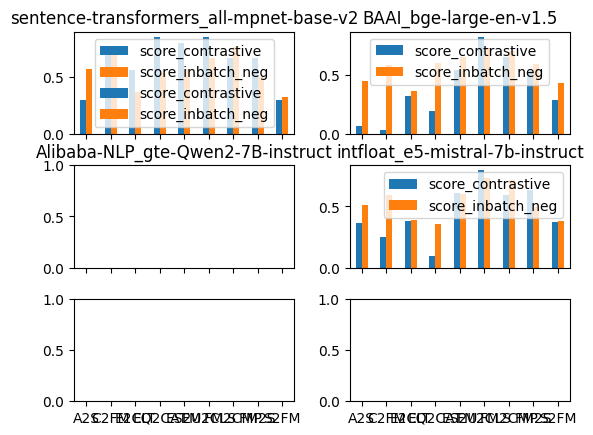

In [98]:
nrows = 3
ncols = 2
fig, ax = plt.subplots(nrows=nrows, sharex=True, ncols=ncols)
# fig.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.25)
for i, model_id in enumerate(model_ids):
    ax[i//nrows][i%ncols].set_title(model_id)
    sel_df = df[df.task==task].copy()  
    rounded_scores = [round((x * 100), 0) for x in sel_df.score.tolist()]
    sel_df.score = rounded_scores
    # ax[i//nrows][i%ncols].plot([0.0, 0.2, 0.4, 0.6, 0.8, 1.0], rounded_scores)
    if 'Alibaba' in model_id:
        continue
    scores_df[scores_df.model_id==model_id].plot(x='task', kind='bar', stacked=False, ax=ax[i//nrows][i%ncols])